# Лабораторная работа № 4

## Библиотеки

In [1]:
import os
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ["DISPLAY"] = ":1"  # создание виртуального дисплея для рисования изображения, если нет монитора
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import gymnasium as gym
from gymnasium.core import ObservationWrapper
from collections import defaultdict
import random

## Класс QLearningAgent

У этого класса есть следующие переменные и функции:

- *epsilon* - вероятность случайного выбора
- *alpha* - скорость обучения
- *discount* - дисконт, она же гамма
- *get_legal_actions(state)* - возвращает разрешённые действия для состояния; состояния и действия хэшируются
- *get_qvalue(state, action)* - возвращает Q-значение для состояния и действия
- *set_qvalue(state, action)* - устанавливает Q-значение для состояния и действия
- *get_value(state)* - вычисляет оценку агента $V(s)$, используя текущее Q-значение
    - $V(s) = \max_aQ(s, a)$
- *update(state, action, reward, next_state)* - обновление Q-значения
    - $Q(s, a) := (1 - α) · Q(s, a) + α · (r + γ · V(s'))$
        - $s'$ - следующее состояние (next_state)
        - $r$ - вознаграждение (reward)
- *get_best_action(state)* - возвращает наилучшее действие для состояния, используя текущее Q-значение
    - $π^*(s) = argmax_aQ(s, a)$ 
- *get_action(state)* - возвращает действие, которое нужно предпринять в текущем состоянии, включая исследование; с вероятностью *epsilon* принимается случайное действие, иначе - лучшее действие политики из *get_best_action(state)*

In [2]:
class QLearningAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions):
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount
        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))

    def get_qvalue(self, state, action):
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        self._qvalues[state][action] = value

    def get_value(self, state):
        possible_actions = self.get_legal_actions(state)

        if len(possible_actions) == 0:  # если нет разрешённых действий, вернуть 0
            return 0.0

        return max([self.get_qvalue(state, action) for action in possible_actions])

    def update(self, state, action, reward, next_state):
        alpha, Q, gamma, V = self.alpha, self.get_qvalue(state, action), self.discount, self.get_value(next_state)

        self.set_qvalue(state, action, (1 - alpha) * Q + alpha * (reward + gamma * V))

    def get_best_action(self, state):
        possible_actions = self.get_legal_actions(state)

        if len(possible_actions) == 0:  # если нет разрешённых действий, вернуть None
            return None

        action_values = [(action, self.get_qvalue(state, action)) for action in possible_actions]
        
        return max(action_values, key=lambda x: x[1])[0]

    def get_action(self, state):
        possible_actions = self.get_legal_actions(state)

        if len(possible_actions) == 0:  # если нет разрешённых действий, вернуть None
            return None

        if random.uniform(0, 1) < self.epsilon:
            return random.choice(possible_actions)
            
        return self.get_best_action(state)        

### Тестирование на среде такси

In [3]:
env = gym.make("Taxi-v3")
n_actions = env.action_space.n
agent = QLearningAgent(alpha=0.5, epsilon=0.25, discount=0.99, get_legal_actions=lambda s: range(n_actions))

Теперь создаём функцию, которая

1. Запустит полную игру с действиями, заданными политикой e-greeding агента
2. Обучит агента через agent.update(), когда это возможно
3. Вернёт общую награду

In [4]:
def play_and_train(env, agent, t_max=10**4):
    total_reward = 0.0
    state = env.reset()[0]

    for t in range(t_max):
        action = agent.get_action(state)

        next_state, reward, terminated, truncated, _ = env.step(action)

        agent.update(state, action, reward, next_state)

        state = next_state

        total_reward += reward

        if terminated or truncated:
            break

    return total_reward

Вывод на график

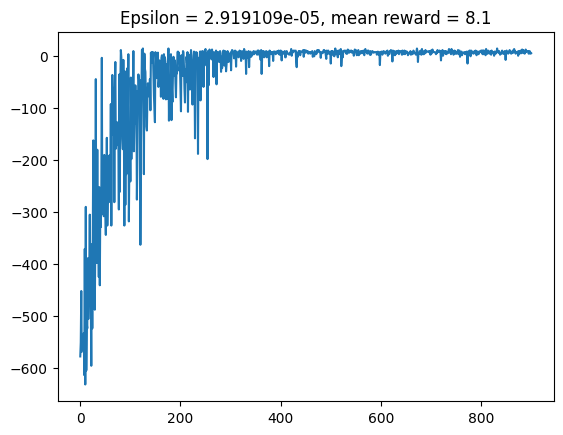

In [5]:
rewards = []

for i in range(1000):
    rewards.append(play_and_train(env, agent))
    agent.epsilon *= 0.99

    if i % 100 == 0:
        clear_output(True)
        plt.title(f"Epsilon = {agent.epsilon:e}, mean reward = {np.mean(rewards[-10:]):.1f}")
        plt.plot(rewards)
        plt.show()

## Бинаризованные пространства состояний